# Sparse Identification of Nonlinear Dynamics (SINDy)

The SINDy (Sparse Identification of Nonlinear Dynamics) algorithm is a data-driven machine learning technique used to discover the governing mathematical equations of a dynamical system directly from measurement data. Developed by researchers at the University of Washington, it leverages sparsity-promoting techniques to find the fewest, most interpretable terms needed to describe a system's behavior.

Let's begin with a simple pendulum example.

---

Consider:

$$\ddot{\theta} = -\frac{g}{L}\sin{\theta}$$

The Challenge: Given only measurements of a pendulum's angle θ and angular velocity ω over time, can we recover the differential equation?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Physical parameters
g = 9.81  # gravity (m/s^2)
L = 1.0   # pendulum length (m)

def pendulum(t, state):
    """Nonlinear pendulum dynamics."""
    theta, omega = state
    dtheta_dt = omega
    domega_dt = -(g / L) * np.sin(theta)
    return [dtheta_dt, domega_dt]

# Initial conditions: release from 60 degrees with zero velocity
theta0 = np.pi / 3  # 60 degrees in radians
omega0 = 0.0
state0 = [theta0, omega0]

# Time span
t_span = (0, 10)  # 10 seconds
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Solve
solution = solve_ivp(pendulum, t_span, state0, t_eval=t_eval, rtol=1e-10)
t = solution.t
theta = solution.y[0]
omega = solution.y[1]

# Stack into data matrix
X = np.column_stack([theta, omega])

print(f"Generated {len(t)} data points over {t[-1]:.1f} seconds")
print(f"Data shape: {X.shape}")

Generated 500 data points over 10.0 seconds
Data shape: (500, 2)


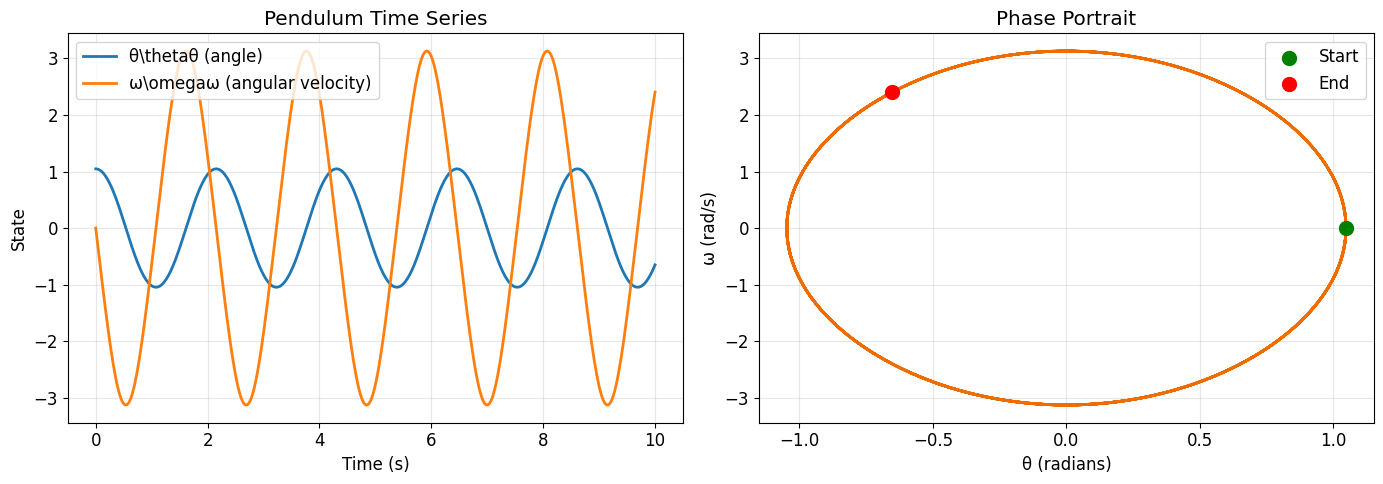

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series
axes[0].plot(t, theta, label=r'θ\thetaθ (angle)', linewidth=2)
axes[0].plot(t, omega, label=r'ω\omegaω (angular velocity)', linewidth=2)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('State')
axes[0].set_title('Pendulum Time Series')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Phase portrait
axes[1].plot(theta, omega, linewidth=2, color='#EF6C00')
axes[1].scatter(theta[0], omega[0], color='green', s=100, zorder=5, label='Start')
axes[1].scatter(theta[-1], omega[-1], color='red', s=100, zorder=5, label='End')
axes[1].set_xlabel(r'θ (radians)')
axes[1].set_ylabel(r'ω (rad/s)')
axes[1].set_title('Phase Portrait')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Create combined library: polynomials + trigonometric
poly_lib = ps.PolynomialLibrary(degree=3)
fourier_lib = ps.FourierLibrary()
library = poly_lib + fourier_lib

# To see what functions are in the library, we need to fit it first
# Create a small sample to fit the library
sample_data = X[:1]  # Just use first data point
library.fit(sample_data)

# Now we can get the feature names
feature_names = library.get_feature_names(input_features=['theta', 'omega'])

print("Combined Library contains {} candidate functions:".format(len(feature_names)))
print("=" * 60)

print("\nPolynomial functions:")
for i, name in enumerate(feature_names):
    if 'sin' not in name and 'cos' not in name:
        print(f"  {i:2d}. {name}")

print("\nTrigonometric functions:")
for i, name in enumerate(feature_names):
    if 'sin' in name or 'cos' in name:
        print(f"  {i:2d}. {name}")

print("\n" + "=" * 60)
print("SINDy will identify which of these functions are needed")
print("by setting most coefficients to zero (sparsity)")

Combined Library contains 14 candidate functions:

Polynomial functions:
   0. 1
   1. theta
   2. omega
   3. theta^2
   4. theta omega
   5. omega^2
   6. theta^3
   7. theta^2 omega
   8. theta omega^2
   9. omega^3

Trigonometric functions:
  10. sin(1 theta)
  11. cos(1 theta)
  12. sin(1 omega)
  13. cos(1 omega)

SINDy will identify which of these functions are needed
by setting most coefficients to zero (sparsity)


In [6]:
# Set up SINDy model
differentiation = ps.FiniteDifference()
optimizer = ps.STLSQ(threshold=0.5, max_iter=20)

model = ps.SINDy(
    differentiation_method=differentiation,
    feature_library=library,
    optimizer=optimizer
)

# Fit the model
model.fit(X, t=t, feature_names=['theta', 'omega'])

# Print discovered equations
print("\nDiscovered equations:")
print("=" * 50)
model.print()


Discovered equations:
(theta)' =  0.999 omega
(omega)' = -0.218 theta +  0.027 theta^3 + -9.580 sin(1 theta)


In [7]:
# Get actual feature names and coefficients
coefficients = model.coefficients()
feature_names = model.get_feature_names()

print("\nCoefficient matrix:")
print(coefficients)
print(f"\nShape: {coefficients.shape} = [equations × library functions]")
print(f"Rows = equations: [theta_dot, omega_dot]")
print(f"Columns = {coefficients.shape[1]} library functions")

print("\nLibrary functions:")
for i, name in enumerate(feature_names):
    print(f"  {i:2d}. {name}")

print("\nNon-zero terms in discovered equations:")

print("\ntheta_dot equation:")
nonzero_idx = np.abs(coefficients[0, :]) > 1e-10
if np.any(nonzero_idx):
    for i in range(len(feature_names)):
        if nonzero_idx[i]:
            print(f"  {coefficients[0, i]:+.6f} * {feature_names[i]}")
else:
    print("  (all coefficients below threshold)")

print("\nomega_dot equation:")
nonzero_idx = np.abs(coefficients[1, :]) > 1e-10
if np.any(nonzero_idx):
    for i in range(len(feature_names)):
        if nonzero_idx[i]:
            print(f"  {coefficients[1, i]:+.6f} * {feature_names[i]}")
else:
    print("  (all coefficients below threshold)")


Coefficient matrix:
[[ 0.          0.          0.99943403  0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.         -0.21769603  0.          0.          0.          0.
   0.02722368  0.          0.          0.         -9.5797099   0.
   0.          0.        ]]

Shape: (2, 14) = [equations × library functions]
Rows = equations: [theta_dot, omega_dot]
Columns = 14 library functions

Library functions:
   0. 1
   1. theta
   2. omega
   3. theta^2
   4. theta omega
   5. omega^2
   6. theta^3
   7. theta^2 omega
   8. theta omega^2
   9. omega^3
  10. sin(1 theta)
  11. cos(1 theta)
  12. sin(1 omega)
  13. cos(1 omega)

Non-zero terms in discovered equations:

theta_dot equation:
  +0.999434 * omega

omega_dot equation:
  -0.217696 * theta
  +0.027224 * theta^3
  -9.579710 * sin(1 theta)


In [8]:
# New initial condition: 45 degrees with initial velocity
theta0_test = np.pi / 4  # 45 degrees
omega0_test = 1.0        # 1 rad/s initial velocity
state0_test = [theta0_test, omega0_test]

# True solution
t_test = np.linspace(0, 10, 500)
solution_test = solve_ivp(pendulum, (0, 10), state0_test, t_eval=t_test, rtol=1e-10)
X_test_true = solution_test.y.T

# SINDy prediction
X_test_pred = model.simulate(state0_test, t_test)

print(f"Prediction shape: {X_test_pred.shape}")

Prediction shape: (500, 2)


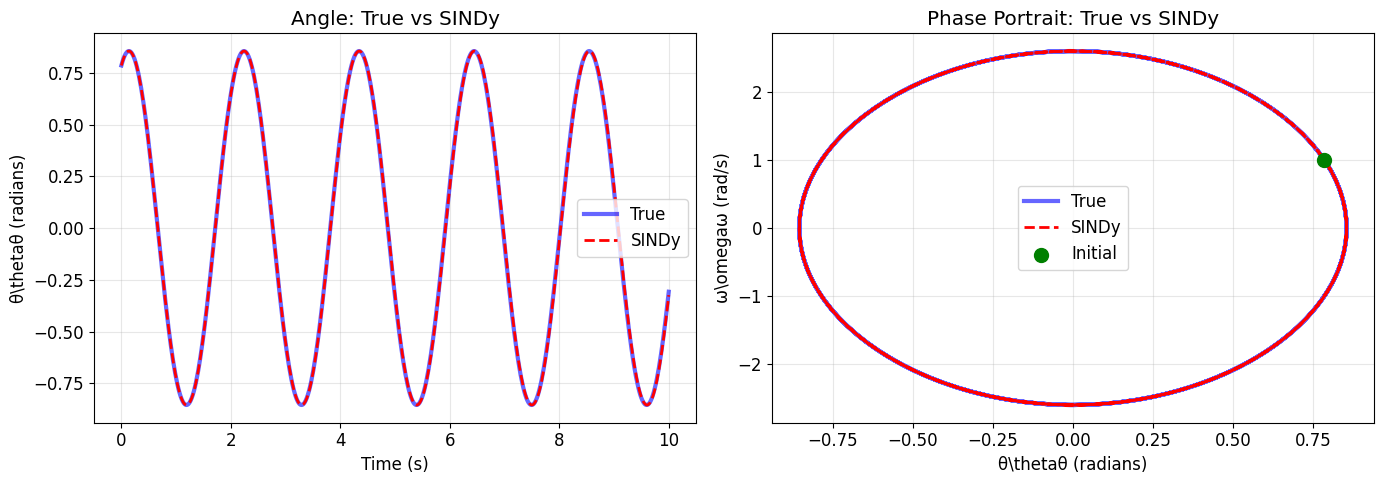

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series comparison
axes[0].plot(t_test, X_test_true[:, 0], 'b-', linewidth=3, alpha=0.6, label='True')
axes[0].plot(t_test, X_test_pred[:, 0], 'r--', linewidth=2, label='SINDy')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel(r'θ\thetaθ (radians)')
axes[0].set_title('Angle: True vs SINDy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Phase portrait comparison
axes[1].plot(X_test_true[:, 0], X_test_true[:, 1], 'b-', linewidth=3, alpha=0.6, label='True')
axes[1].plot(X_test_pred[:, 0], X_test_pred[:, 1], 'r--', linewidth=2, label='SINDy')
axes[1].scatter(theta0_test, omega0_test, color='green', s=100, zorder=5, label='Initial')
axes[1].set_xlabel(r'θ\thetaθ (radians)')
axes[1].set_ylabel(r'ω\omegaω (rad/s)')
axes[1].set_title('Phase Portrait: True vs SINDy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Mean absolute error in theta: 0.005457 rad
Max absolute error in theta:  0.016312 rad
Mean absolute error in omega: 0.017057 rad/s
Max absolute error in omega:  0.048318 rad/s


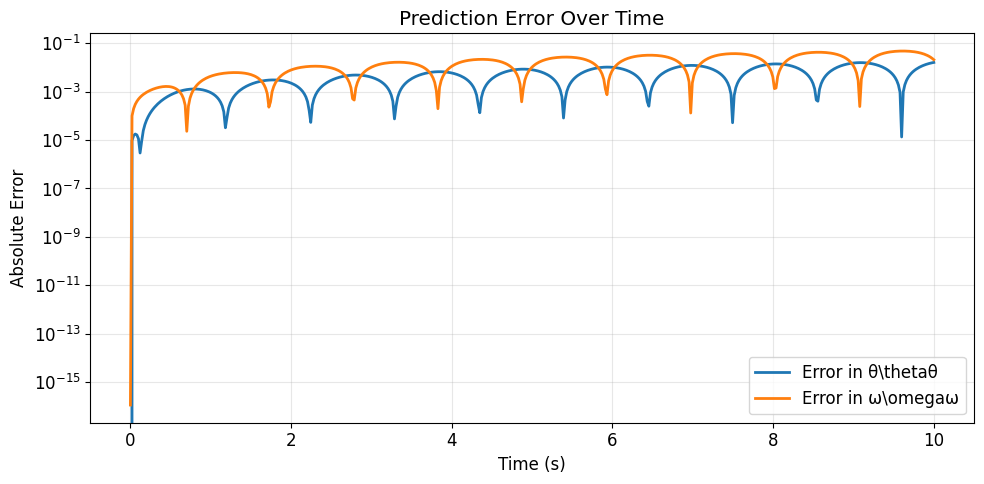

In [10]:
# Compute errors
error_theta = np.abs(X_test_true[:, 0] - X_test_pred[:, 0])
error_omega = np.abs(X_test_true[:, 1] - X_test_pred[:, 1])

print(f"Mean absolute error in theta: {np.mean(error_theta):.6f} rad")
print(f"Max absolute error in theta:  {np.max(error_theta):.6f} rad")
print(f"Mean absolute error in omega: {np.mean(error_omega):.6f} rad/s")
print(f"Max absolute error in omega:  {np.max(error_omega):.6f} rad/s")

# Plot error over time
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(t_test, error_theta, label=r'Error in θ\thetaθ', linewidth=2)
ax.semilogy(t_test, error_omega, label=r'Error in ω\omegaω', linewidth=2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Absolute Error')
ax.set_title('Prediction Error Over Time')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment: What if we use the wrong library?

In [11]:
# Try with only polynomials
model_poly = ps.SINDy(
    differentiation_method=ps.FiniteDifference(),
    feature_library=ps.PolynomialLibrary(degree=5),
    optimizer=ps.STLSQ(threshold=0.3)
)

model_poly.fit(X, t=t, feature_names=['theta', 'omega'])

print("\nDiscovered equations (polynomial library only):")
print("=" * 50)
model_poly.print()


Discovered equations (polynomial library only):
(theta)' =  4.839 theta^2 omega + -4.408 theta^4 omega
(omega)' = -3.935 theta + -4.003 theta^3 + -0.598 theta omega^2 +  0.178 theta^5 + -0.024 theta^3 omega^2


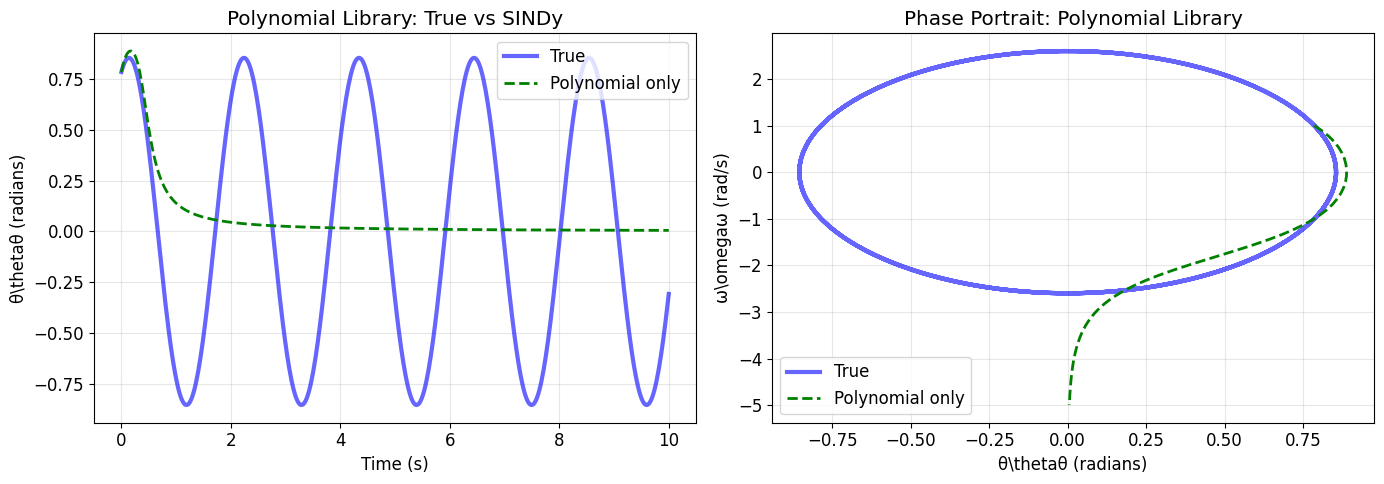


Note: Polynomial approximation of sin(theta) works for small angles,
but diverges for larger oscillations.


In [12]:
X_test_poly = model_poly.simulate(state0_test, t_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series
axes[0].plot(t_test, X_test_true[:, 0], 'b-', linewidth=3, alpha=0.6, label='True')
axes[0].plot(t_test, X_test_poly[:, 0], 'g--', linewidth=2, label='Polynomial only')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel(r'θ\thetaθ (radians)')
axes[0].set_title('Polynomial Library: True vs SINDy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Phase portrait
axes[1].plot(X_test_true[:, 0], X_test_true[:, 1], 'b-', linewidth=3, alpha=0.6, label='True')
axes[1].plot(X_test_poly[:, 0], X_test_poly[:, 1], 'g--', linewidth=2, label='Polynomial only')
axes[1].set_xlabel(r'θ\thetaθ (radians)')
axes[1].set_ylabel(r'ω\omegaω (rad/s)')
axes[1].set_title('Phase Portrait: Polynomial Library')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Polynomial approximation of sin(theta) works for small angles,")
print("but diverges for larger oscillations.")

# YOUR TURN! 

### Consider the following Dynamical System
The system of differential equations is given by:

$$
\frac{d}{dt} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} -2 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix}
$$

### Decoupled Solutions
The system decouples into two independent differential equations with the following general solutions:

$$
x(t) = x_0 e^{-2t}
$$
$$
y(t) = y_0 e^t
$$

### Specific Solutions
Using the initial conditions $x_0 = 3$ and $y_0 = \frac{1}{2}$, the specific trajectory equations are:

$$
x(t) = 3e^{-2t}
$$
$$
y(t) = \frac{1}{2}e^t
$$

### Data Matrix Construction
Given $N$ position measurements at distinct times $t_1, t_2, \dots, t_N$, the $2 \times N$ data matrix $X$ is constructed as follows:

$$
X = \begin{bmatrix} 
x(t_1) & x(t_2) & \dots & x(t_N) \\ 
y(t_1) & y(t_2) & \dots & y(t_N) 
\end{bmatrix}
$$

Substituting the specific solutions into the matrix yields:

$$
X = \begin{bmatrix} 
3e^{-2t_1} & 3e^{-2t_2} & \dots & 3e^{-2t_N} \\ 
\frac{1}{2}e^{t_1} & \frac{1}{2}e^{t_2} & \dots & \frac{1}{2}e^{t_N} 
\end{bmatrix}
$$

Use SINDy to recover a system of differential equations with initial conditions $x_0 = 3$ and $x_1 = \frac{1}{2}$.

In [ ]:
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt


def gen_data1():
    t = np.linspace(0, 1, 100)
    x = 3 * np.exp(-2 * t)
    y = 0.5 * np.exp(t)
    return t, x, y


def gen_data2():
    x0 = 6
    y0 = -0.1
    t_test = np.linspace(0, 1, 100)
    x_test = x0 * np.exp(-2 * t_test)
    y_test = y0 * np.exp(t_test)
    return x0, y0, t_test, x_test, y_test

# 1. Prepare Training Data
t, x, y = gen_data1() 
X = np.stack((x, y), axis=-1) # First column is x, second is y 
dt = t[1] - t[0] # Calculate time step for differentiatio

In [21]:
# 2. Configure PySINDy Components
diff_method = ps.differentiation.FiniteDifference(order=2)
feature_names = ps.feature_library.PolynomialLibrary(degree=3)
optimizer = ps.optimizers.STLSQ(threshold=0.2)

In [24]:
# 3. Initialize the SINDy Model (Remove feature_names here)
model = ps.SINDy(
    differentiation_method=diff_method,
    feature_library=feature_library,
    optimizer=optimizer
)
dt = t[1] - t[0]
# 4. Fit the Model (Pass feature_names here instead)
model.fit(X, t=dt, feature_names=["x", "y"])

,optimizer,STLSQ(threshold=0.2)
,feature_library,PolynomialLibrary(degree=3)
,differentiation_method,FiniteDifference()
Name,Type,Value
n_control_features_,int,0
n_features_in_,int,2
n_output_features_,int,10
,degree,3
,include_interaction,True
,interaction_only,False
,include_bias,True


In [26]:
# 4. Print Discovered Equations
print("Discovered Equations:")
model.print()

# 5. Evaluate on Test Data (Optional)
x0, y0, t_test, x_test, y_test = gen_data2()
X_test = np.stack((x_test, y_test), axis=-1)

# Simulates the system forward in time using discovered equations
X_sim = model.simulate(X_test[0], t_test) 

Discovered Equations:
(x)' = -2.000 x
(y)' =  1.000 y


Text(0.5, 1.0, 'SINDy Model Simulation Comparison')

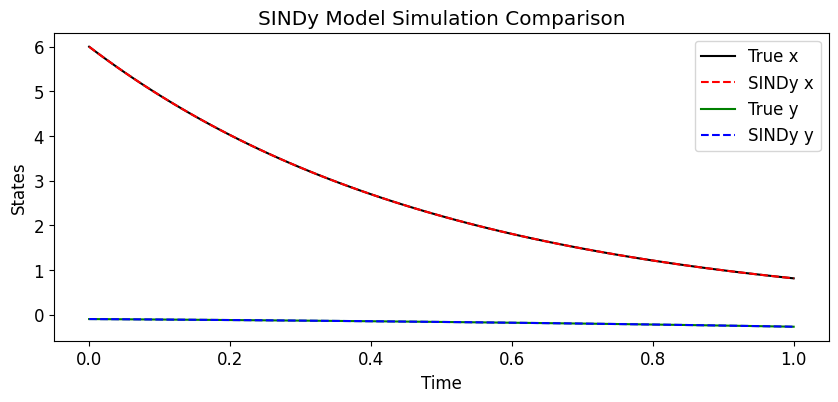

In [33]:
# 6. Plot Results
plt.figure(figsize=(10, 4))
plt.plot(t_test, X_test[:, 0], 'k', label="True x")
plt.plot(t_test, X_sim[:, 0], 'r--', label="SINDy x")
plt.plot(t_test, X_test[:, 1], 'g', label="True y")
plt.plot(t_test, X_sim[:, 1], 'b--', label="SINDy y")
plt.xlabel("Time")
plt.ylabel("States")
plt.legend()
plt.title("SINDy Model Simulation Comparison")

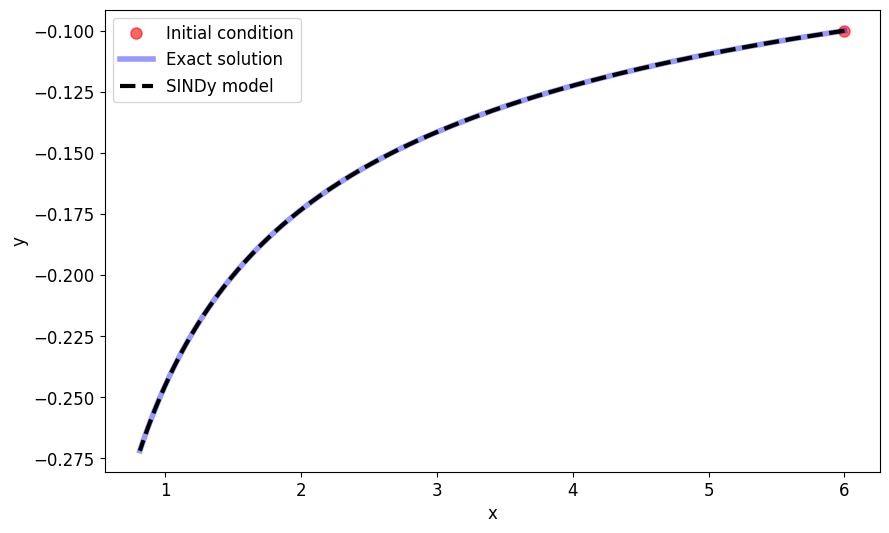

In [29]:
sim = model.simulate(X_test[0, :], t_test)

plt.ion()

plt.figure()
plt.plot(x0, y0, "ro", label="Initial condition", alpha=0.6, markersize=8)
plt.plot(x_test, y_test, "b", label="Exact solution", alpha=0.4, linewidth=4)
plt.plot(sim[:, 0], sim[:, 1], "k--", label="SINDy model", linewidth=3)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()